# The scoreboard

### Every method, every house dataset, one table, and why the order keeps changing

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How to build one evaluation harness that produces every cell of a comparison table identically, how to measure the properties of a dataset that decide which family of model wins on it, and how to read a scoreboard without being fooled by a win worth two thousandths of a point |
| **You should already know** | [Cross-validation](../../01-foundations/04-cross-validation/), and roughly what each method in the book does — [logistic regression](../../03-classification/01-logistic-regression/), [k-NN](../../03-classification/02-k-nearest-neighbours/), [naive Bayes](../../03-classification/03-naive-bayes/), [SVMs](../../03-classification/05-support-vector-machines/), [trees](../../03-classification/06-decision-trees/), [random forests](../../04-ensembles/02-random-forest/), [gradient boosting](../../04-ensembles/05-gradient-boosting/), [MLPs](../../07-neural-networks/02-mlp-and-backpropagation/) |
| **Datasets** | UCI Dry Bean, Breast Cancer Wisconsin, California Housing, UCI Bike Sharing |
| **Runtime** | Six to eight minutes on a laptop CPU. Gradient boosting and the MLP rows are most of it |
| **Next** | [12-02 Interpreting models](../02-interpreting-models/) |

---

## 1. Why this chapter exists

Every notebook in this book used the same handful of datasets. That was not
laziness. It was so that this chapter could exist.

When a tutorial tells you gradient boosting scored 0.94 and another tells you an
SVM scored 0.91, you have learned nothing, because the two numbers came from
different data, different splits, different preprocessing and probably different
amounts of tuning. Put them on the same data with the same folds and the same
scaling rule, and the difference means something.

So this chapter runs eighteen estimators across four datasets through a single
function, and then does the part that most comparison tables skip: it measures
what is different about each dataset and connects those measurements to which
family came out on top.

Two warnings before the numbers.

**Nothing here is tuned.** Every method uses a sensible default setting, stated
in the code. A tuned SVM would beat an untuned one, and the ordering would move.
What you are reading is the ordering you get when you reach for a method and run
it, which is what most people actually do first.

**Every dataset is capped at six thousand rows.** Dry bean, California housing
and bike sharing are all larger than that; each is randomly subsampled down so
the whole notebook finishes in minutes rather than an afternoon, and so that an
RBF kernel SVM — which costs roughly the square of the row count — stays
affordable. Absolute scores would move up a little on the full data. The
ordering, in my experience, mostly does not.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

## 2. The harness

One function, `score`, takes an estimator and a dataset and returns a
cross-validated result. Every cell in every table below is produced by that
function and nothing else, so when two rows differ, the estimator is the only
thing that differed.

The rules it fixes:

Five folds, shuffled, seed zero. Stratified for classification so the rare bean
varieties appear in every fold, plain for regression.

Scaling lives *inside* a pipeline, so the scaler is refitted on each training
fold and never sees the fold it is scored on. Scaling is applied to every
method, including the trees, where it makes no difference at all — a decision
tree splits on order, and standardising a column does not change the order.
Keeping it uniform is worth more than saving a microsecond.

For the regression side the *target* is standardised too, and un-standardised
again before scoring. That is there so a penalty strength like ridge's `alpha`
means the same thing on a target measured in hundreds of thousands of dollars as
on one measured in bicycles per hour. Without it, the same alpha is heavy
regularisation on one dataset and no regularisation on the other, and the two
columns stop being comparable. R-squared is unaffected by the transform for
every unpenalised model.

Folds run in parallel, five at a time, but each estimator is pinned to a single
thread. That is so the fit-time column measures something: a random forest given
eight cores would look artificially cheap next to an SVM that cannot use them.

In [2]:
import time
import warnings
from dataclasses import dataclass

from sklearn.compose import TransformedTargetRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import (KFold, StratifiedKFold, cross_val_score,
                                     cross_validate)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Untuned defaults on four different datasets will not all converge. That is part
# of what "untuned" means, and the warnings would drown the output.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

CAP = 6000        # rows kept per dataset, so the whole notebook runs in minutes
N_FOLDS = 5
CV_JOBS = 5       # one process per fold; estimators stay single-threaded


@dataclass
class Task:
    """A dataset plus what kind of problem it is. The harness needs both."""
    name: str
    kind: str          # "classification" or "regression"
    X: np.ndarray
    y: np.ndarray
    columns: list


def load_task(name, kind, loader):
    X, y = loader()
    X = X.select_dtypes(include="number")
    if len(X) > CAP:
        idx = np.random.default_rng(SEED).permutation(len(X))[:CAP]
        X, y = X.iloc[idx], y.iloc[idx]
    return Task(name, kind, X.to_numpy(dtype=float), y.to_numpy(), list(X.columns))


TASKS = [
    load_task("dry bean", "classification", datasets.dry_bean),
    load_task("breast cancer", "classification", datasets.breast_cancer),
    load_task("california housing", "regression", datasets.california_housing),
    load_task("bike sharing", "regression", datasets.bike_sharing),
]

for task in TASKS:
    labels = len(np.unique(task.y)) if task.kind == "classification" else None
    extra = f", {labels} classes" if labels else ""
    print(f"{task.name:<19} {task.kind:<15} {task.X.shape[0]:>5} rows x "
          f"{task.X.shape[1]:>2} columns{extra}")

dry bean            classification   6000 rows x 16 columns, 7 classes
breast cancer       classification    569 rows x 30 columns, 2 classes
california housing  regression       6000 rows x  8 columns
bike sharing        regression       6000 rows x 12 columns


In [3]:
def wrap(model, kind):
    """Put the estimator behind the same preprocessing every time.

    Scaling is refitted per fold inside the pipeline, which is the only way to
    keep the validation fold genuinely unseen.
    """
    steps = make_pipeline(StandardScaler(), model)
    if kind == "regression":
        # Standardise y as well, so alpha means the same thing on both targets.
        return TransformedTargetRegressor(regressor=steps, transformer=StandardScaler())
    return steps


def score(model, task):
    """One cell of the scoreboard: cross-validated quality, spread, and cost."""
    if task.kind == "classification":
        folds = StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED)
        metric = "accuracy"
    else:
        folds = KFold(N_FOLDS, shuffle=True, random_state=SEED)
        metric = "r2"

    out = cross_validate(wrap(model, task.kind), task.X, task.y,
                         cv=folds, scoring=metric, n_jobs=CV_JOBS)
    return {"score": out["test_score"].mean(),
            "sd": out["test_score"].std(),
            "fit_seconds": out["fit_time"].mean()}


def run(models, kinds):
    """Every model against every task of the matching kind."""
    rows = []
    for task in TASKS:
        if task.kind not in kinds:
            continue
        started = time.perf_counter()
        for name, build in models.items():
            rows.append({"method": name, "dataset": task.name,
                         **score(build(), task)})
        print(f"{task.name:<19} done in {time.perf_counter() - started:5.1f} s")
    return pd.DataFrame(rows)

## 3. The classification table

Ten methods, from the cheapest linear model to a small neural network. The
settings are the ones a person types without thinking: a hundred and fifty trees
in the forests, ten neighbours for k-NN, a two-layer MLP with a hard cap on
epochs and early stopping.

`n_jobs=1` everywhere is deliberate, for the timing column.

In [4]:
from sklearn.ensemble import (ExtraTreesClassifier, GradientBoostingClassifier,
                              RandomForestClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier

CLASSIFIERS = {
    "logistic regression": lambda: LogisticRegression(max_iter=3000),
    "k-NN (k=10)":         lambda: KNeighborsClassifier(n_neighbors=10, n_jobs=1),
    "naive Bayes":         lambda: GaussianNB(),
    "linear SVM":          lambda: LinearSVC(C=1.0, max_iter=8000, random_state=SEED),
    "RBF SVM":             lambda: SVC(C=1.0, gamma="scale", cache_size=500,
                                       random_state=SEED),
    "decision tree":       lambda: DecisionTreeClassifier(random_state=SEED),
    "random forest":       lambda: RandomForestClassifier(n_estimators=150, n_jobs=1,
                                                          random_state=SEED),
    "extra trees":         lambda: ExtraTreesClassifier(n_estimators=150, n_jobs=1,
                                                        random_state=SEED),
    "gradient boosting":   lambda: GradientBoostingClassifier(n_estimators=100,
                                                              random_state=SEED),
    "MLP (64, 32)":        lambda: MLPClassifier(hidden_layer_sizes=(64, 32),
                                                 max_iter=300, early_stopping=True,
                                                 n_iter_no_change=10, random_state=SEED),
}

clf = run(CLASSIFIERS, {"classification"})

CLF_SETS = ["dry bean", "breast cancer"]
clf_score = clf.pivot(index="method", columns="dataset",
                      values="score").loc[list(CLASSIFIERS), CLF_SETS]
clf_time = clf.pivot(index="method", columns="dataset",
                     values="fit_seconds").loc[list(CLASSIFIERS), CLF_SETS]
clf_sd = clf.pivot(index="method", columns="dataset",
                   values="sd").loc[list(CLASSIFIERS), CLF_SETS]

print("\nmean accuracy over 5 folds")
print(clf_score.round(4).to_string())
print("\nstandard deviation across folds")
print(clf_sd.round(4).to_string())

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\pipeline.py", line 621, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "C:\Users\pilot\AppData\Local\Program

NameError: name 'clf_score' is not defined

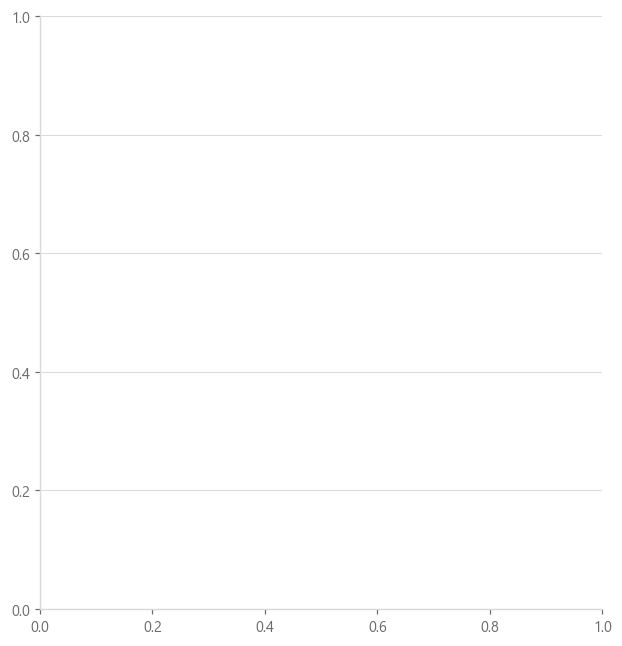

In [5]:
from matplotlib.colors import LinearSegmentedColormap

# White for last place, the highlight colour for first, so the eye reads a column
# as an ordering rather than as a set of unrelated numbers.
BOARD = LinearSegmentedColormap.from_list("board", ["#ffffff", "#f7dcc8", style.HIGHLIGHT])


def draw_board(ax, table, fmt="{:.3f}"):
    """A heatmap shaded by rank within each column, annotated with the raw score."""
    ranks = table.rank(ascending=False, axis=0, method="min")
    shade = (1 - (ranks - 1) / (len(table) - 1)).to_numpy()
    ax.imshow(shade, cmap=BOARD, vmin=0, vmax=1, aspect="auto")
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            ax.text(j, i, fmt.format(table.iat[i, j]) + f"\n#{int(ranks.iat[i, j])}",
                    ha="center", va="center", fontsize=8.5,
                    color="white" if shade[i, j] > 0.62 else style.INK)
    ax.set_xticks(range(table.shape[1]), list(table.columns))
    ax.set_yticks(range(table.shape[0]), list(table.index))
    ax.tick_params(length=0)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    return ranks


fig, ax = plt.subplots(figsize=(6.6, 7.0))
clf_rank = draw_board(ax, clf_score)
style.title(ax, "The order is not the same in both columns",
            "5-fold accuracy, subsampled to 6,000 rows, untuned defaults")
style.save(fig, FIG / "fig-01-classification-scoreboard.png")

print("winner per dataset")
for name in CLF_SETS:
    top = clf_score[name].idxmax()
    print(f"  {name:<15} {top:<20} {clf_score.loc[top, name]:.4f}   "
          f"({clf_time.loc[top, name]:.2f} s per fit)")

Two columns, ten rows, and already the two columns need not agree on an order.
Read down each of them and look for methods that sit near the top on one dataset
and in the lower half on the other.

The fold-to-fold standard deviations are worth a look before you take any of
this too seriously. Breast cancer has 569 rows, so a fold is about a hundred
rows, and one extra mistake moves the accuracy by nearly a percentage point.
Compare each gap in that column against the spread across folds; on a dataset
this small, some of what looks like a gap will not be one.

## 4. The regression table

Eight methods this time. There is no naive Bayes or SVM equivalent worth
including, and the linear family splits into three: plain, ridge, and lasso.
Scoring is R-squared, so higher is better and the columns read the same
direction as the classification ones.

In [6]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor

REGRESSORS = {
    "linear regression": lambda: LinearRegression(),
    "ridge":             lambda: Ridge(alpha=1.0),
    "lasso":             lambda: Lasso(alpha=0.1, max_iter=10000),
    "k-NN (k=10)":       lambda: KNeighborsRegressor(n_neighbors=10, n_jobs=1),
    "decision tree":     lambda: DecisionTreeRegressor(random_state=SEED),
    "random forest":     lambda: RandomForestRegressor(n_estimators=150, n_jobs=1,
                                                       random_state=SEED),
    "gradient boosting": lambda: GradientBoostingRegressor(n_estimators=150,
                                                           random_state=SEED),
    "MLP (64, 32)":      lambda: MLPRegressor(hidden_layer_sizes=(64, 32),
                                              max_iter=300, early_stopping=True,
                                              n_iter_no_change=10, random_state=SEED),
}

reg = run(REGRESSORS, {"regression"})

REG_SETS = ["california housing", "bike sharing"]
reg_score = reg.pivot(index="method", columns="dataset",
                      values="score").loc[list(REGRESSORS), REG_SETS]
reg_time = reg.pivot(index="method", columns="dataset",
                     values="fit_seconds").loc[list(REGRESSORS), REG_SETS]
reg_sd = reg.pivot(index="method", columns="dataset",
                   values="sd").loc[list(REGRESSORS), REG_SETS]

print("\nmean R-squared over 5 folds")
print(reg_score.round(4).to_string())
print("\nstandard deviation across folds")
print(reg_sd.round(4).to_string())

california housing  done in  13.5 s


bike sharing        done in  11.5 s

mean R-squared over 5 folds
dataset            california housing  bike sharing
method                                             
linear regression              0.6439        0.3827
ridge                          0.6439        0.3827
lasso                          0.5254        0.3412
k-NN (k=10)                    0.7242        0.5337
decision tree                  0.5382        0.8565
random forest                  0.7759        0.9243
gradient boosting              0.7916        0.8704
MLP (64, 32)                   0.7738        0.9088

standard deviation across folds
dataset            california housing  bike sharing
method                                             
linear regression              0.0373        0.0051
ridge                          0.0372        0.0051
lasso                          0.0185        0.0067
k-NN (k=10)                    0.0095        0.0083
decision tree                  0.0378        0.0125
random forest     

winner per dataset
  california housing  gradient boosting    0.7916   (2.49 s per fit)
  bike sharing        random forest        0.9243   (4.22 s per fit)

linear family, best of the three
  california housing  0.6439   (gap to the winner: +0.1477)
  bike sharing        0.3827   (gap to the winner: +0.5417)


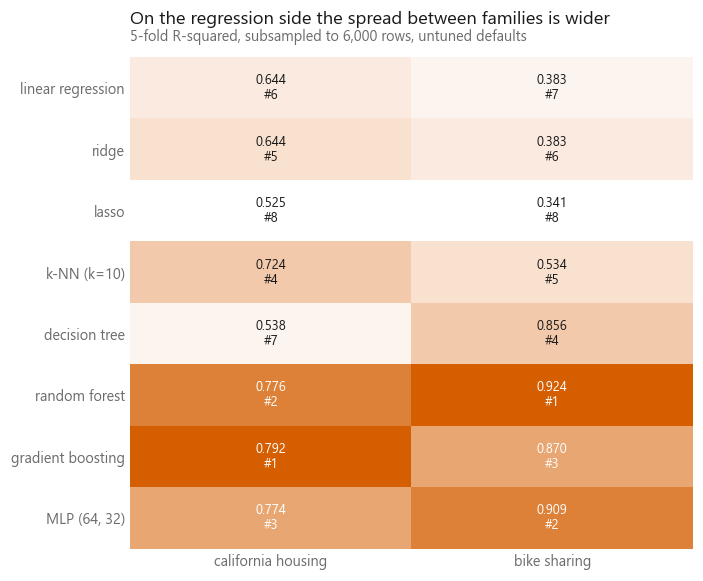

In [7]:
fig, ax = plt.subplots(figsize=(6.6, 5.8))
reg_rank = draw_board(ax, reg_score)
style.title(ax, "On the regression side the spread between families is wider",
            "5-fold R-squared, subsampled to 6,000 rows, untuned defaults")
style.save(fig, FIG / "fig-02-regression-scoreboard.png")

print("winner per dataset")
for name in REG_SETS:
    top = reg_score[name].idxmax()
    print(f"  {name:<19} {top:<20} {reg_score.loc[top, name]:.4f}   "
          f"({reg_time.loc[top, name]:.2f} s per fit)")

print("\nlinear family, best of the three")
for name in REG_SETS:
    linear_best = reg_score.loc[["linear regression", "ridge", "lasso"], name].max()
    print(f"  {name:<19} {linear_best:.4f}   "
          f"(gap to the winner: {reg_score[name].max() - linear_best:+.4f})")

I expect the regression columns to separate the families more clearly than the
classification ones did, and I expect a straight line to get most of the way to
the winner on one of these two datasets and to be left well behind on the other.
If that happens, the reason is a single column of the data, and the next section
measures it rather than asserting it.

### What it cost

Accuracy alone is a bad way to pick a method. A model that wins by two
thousandths of a point and costs fifty times as much to fit has not won
anything, and in production it is the worse choice. So here is quality against
fitting time, on the two largest datasets.

NameError: name 'clf' is not defined

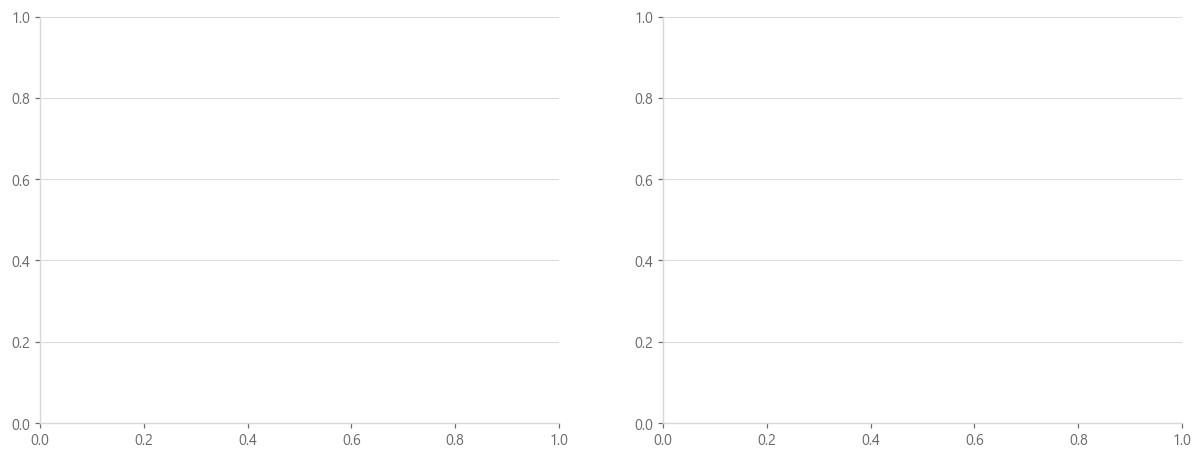

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.8))

panels = [(axes[0], clf[clf["dataset"] == "dry bean"], "dry bean", "accuracy"),
          (axes[1], reg[reg["dataset"] == "bike sharing"], "bike sharing", "R-squared")]

for ax, frame, title_name, ylabel in panels:
    best = frame["score"].max()
    colours = [style.HIGHLIGHT if s == best else style.NEUTRAL for s in frame["score"]]
    ax.scatter(frame["fit_seconds"], frame["score"], c=colours, s=52, zorder=3)
    for row in frame.itertuples():
        ax.annotate(row.method, (row.fit_seconds, row.score), xytext=(6, 4),
                    textcoords="offset points", fontsize=8, color=style.MUTED)
    ax.set_xscale("log")
    ax.set_xlabel("mean fit time per fold (seconds, log scale)")
    ax.set_ylabel(ylabel)
    ax.margins(x=0.22)
    style.title(ax, title_name, "orange is the winner on that dataset")

fig.suptitle("The top of each column is bought with two or three orders of magnitude of compute",
             x=0.5, y=1.04, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-03-quality-against-time.png")

results = pd.concat([clf, reg], ignore_index=True)

print("cheapest method within 0.01 of the best, per dataset")
for task in TASKS:
    frame = results[results["dataset"] == task.name]
    best_row = frame.loc[frame["score"].idxmax()]
    close = frame[frame["score"] >= best_row["score"] - 0.01]
    cheap = close.loc[close["fit_seconds"].idxmin()]
    print(f"  {task.name:<19} best {best_row['method']:<20} {best_row['score']:.4f} "
          f"in {best_row['fit_seconds']:6.2f} s")
    print(f"  {'':<19} good {cheap['method']:<20} {cheap['score']:.4f} "
          f"in {cheap['fit_seconds']:6.2f} s   "
          f"({best_row['fit_seconds'] / max(cheap['fit_seconds'], 1e-6):.0f}x cheaper, "
          f"{cheap['score'] - best_row['score']:+.4f})")

## 5. Why the ranking changes, characterised and measured

This is the section the rest of the notebook exists to reach.

It is easy to write "gradient boosting does well on tabular data with threshold
effects" and leave it there. It is more useful to measure the threshold effects
and then check that the sentence survives. So for each dataset I compute four
properties, all from the data itself, none of them involving the scoreboard
except the second.

**Rows per column.** The number of examples divided by the number of features.
It is the crudest measure of how much a flexible model has to work with, and it
is the one that decides whether a neural network has any chance.

**Linear gap.** How far the best linear model falls short of the best model
overall. Near zero means the problem is essentially a straight line and anything
fancier is spending compute to rediscover that. Large means the target bends,
steps, or interacts.

**Mean absolute pairwise correlation.** How much the columns repeat each other.
Redundant columns hurt distance-based methods, because a fact measured three
times votes three times in a Euclidean distance, and they are exactly what
ridge and lasso were built for.

**Step advantage.** For each feature on its own, how much better a three-level
decision tree does than a straight line. High means the target moves in
thresholds rather than slopes, which is the situation trees were designed for
and the one linear models cannot represent without you building the features by
hand.

That last one is the interesting measurement, because it is computed one column
at a time and so it does not smuggle in interaction effects. It is answering a
narrow question: on this dataset, does knowing which side of a cut a value falls
on tell you more than knowing the value?

In [9]:
def step_advantage(task):
    """Per feature, how much a 3-level step function beats a straight line.

    One column at a time and cross-validated, so it measures curvature and
    thresholds rather than interactions or overfitting.
    """
    if task.kind == "classification":
        folds, metric = StratifiedKFold(3, shuffle=True, random_state=SEED), "accuracy"
        step = DecisionTreeClassifier(max_depth=3, random_state=SEED)
        line = LogisticRegression(max_iter=1000)
    else:
        folds, metric = KFold(3, shuffle=True, random_state=SEED), "r2"
        step = DecisionTreeRegressor(max_depth=3, random_state=SEED)
        line = LinearRegression()

    gaps = []
    for j in range(task.X.shape[1]):
        column = task.X[:, [j]]
        a = cross_val_score(step, column, task.y, cv=folds, scoring=metric).mean()
        b = cross_val_score(make_pipeline(StandardScaler(), line), column, task.y,
                            cv=folds, scoring=metric).mean()
        gaps.append(a - b)
    return float(np.mean(gaps))


def characterise(task):
    n, p = task.X.shape
    Z = StandardScaler().fit_transform(task.X)

    corr = np.nan_to_num(np.corrcoef(Z, rowvar=False))
    off_diagonal = ~np.eye(p, dtype=bool)

    # How many directions the columns really span, via the covariance spectrum.
    spectrum = np.linalg.svd(Z / np.sqrt(n), compute_uv=False) ** 2
    reaches_95 = int(np.searchsorted(np.cumsum(spectrum) / spectrum.sum(), 0.95) + 1)

    return {"rows": n,
            "columns": p,
            "rows per column": n / p,
            "mean |correlation|": float(np.abs(corr[off_diagonal]).mean()),
            "columns for 95% variance": reaches_95,
            "step advantage": step_advantage(task)}


LINEAR_ROWS = {"classification": ["logistic regression", "linear SVM"],
               "regression": ["linear regression", "ridge", "lasso"]}

traits = pd.DataFrame({task.name: characterise(task) for task in TASKS}).T

gaps = {}
for task in TASKS:
    board = clf_score if task.kind == "classification" else reg_score
    linear_best = board.loc[LINEAR_ROWS[task.kind], task.name].max()
    gaps[task.name] = board[task.name].max() - linear_best
traits["linear gap"] = pd.Series(gaps)

print(traits.round(3).to_string())

NameError: name 'clf_score' is not defined

KeyError: 'linear gap'

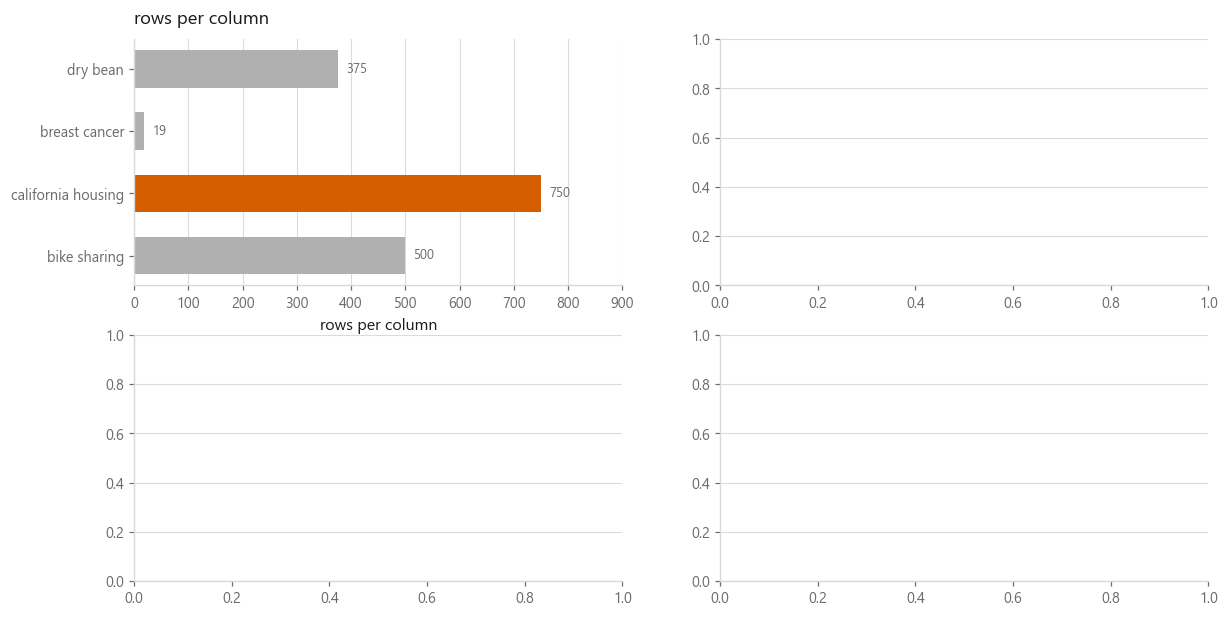

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12.6, 6.4))
order = list(traits.index)[::-1]      # barh draws bottom-up

panels = [("rows per column", "rows per column", "{:.0f}"),
          ("linear gap", "best score minus best linear score", "{:.3f}"),
          ("mean |correlation|", "mean absolute pairwise correlation", "{:.2f}"),
          ("step advantage", "one-feature step function minus one-feature line", "{:.3f}")]

for ax, (column, label, fmt) in zip(axes.ravel(), panels):
    values = traits.loc[order, column].astype(float)
    colours = style.spot(len(order), int(np.argmax(values.to_numpy())))
    ax.barh(order, values, color=colours, height=0.6)
    for i, v in enumerate(values):
        ax.text(v + values.max() * 0.02, i, fmt.format(v), va="center",
                fontsize=8.5, color=style.MUTED)
    ax.set_xlabel(label)
    ax.margins(x=0.2)
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", visible=True)
    style.title(ax, column)

fig.suptitle("Four measurements that between them decide which family wins",
             x=0.5, y=1.03, fontsize=12.5, color=style.INK)
fig.tight_layout()
style.save(fig, FIG / "fig-04-what-makes-them-different.png")

### Reading the four datasets

Now the connections, one dataset at a time. I wrote these as expectations before
running anything, and the cell after them checks each one against the numbers
rather than letting me quietly move the goalposts.

**Breast cancer** is the small one. It has the fewest rows against the most
columns of any dataset here, so I expect the worst rows-per-column ratio of the
four, and its columns repeat each other, because radius, perimeter and area of the
same cell nucleus are three names for one thing. Both facts point the same way:
a flexible model has very little data per direction to learn from, and a linear
boundary in a redundant thirty-dimensional space is already close to the best
available. I expect the linear gap here to be the smallest of the four, and I
expect the neural network to gain nothing over logistic regression.

**Dry bean** has plenty of rows, moderately redundant shape features, and seven
classes whose boundaries are curved rather than straight. Enough data for a
flexible model, so I expect the ensembles and the RBF SVM to lead, and the gap
over the linear models to be real but modest.

**California housing** has only eight columns but two of them are latitude and
longitude, and house prices as a function of latitude are not a slope — they are
a map. That is a threshold effect in the purest form, and it is invisible to a
linear model unless you engineer it. I expect a large step advantage and a large
linear gap.

**Bike sharing** is the extreme case, and it is extreme because of one column.
Hour of day is coded zero to twenty-three, and demand as a function of that
integer has two sharp peaks. A linear model asked to fit demand against hour
fits a nearly flat line through the middle of it. A tree cuts the hour column
either side of each peak and has it. I expect this dataset to have both the
largest step advantage and the largest linear gap of the four, and I expect the
distance between the tree family and the linear family to be the widest anywhere
in this notebook.

In [11]:
ENSEMBLES = {"random forest", "extra trees", "gradient boosting"}

winners = pd.concat([clf_score.idxmax(), reg_score.idxmax()])
fastest = {}
for task in TASKS:
    frame = results[results["dataset"] == task.name]
    fastest[task.name] = frame.loc[frame["fit_seconds"].idxmin(), "method"]

mlp_vs_logistic = (clf_score.loc["MLP (64, 32)", "breast cancer"]
                   - clf_score.loc["logistic regression", "breast cancer"])

expectations = [
    ("a tree ensemble wins on every dataset",
     set(winners) <= ENSEMBLES),
    ("breast cancer has the smallest linear gap",
     traits["linear gap"].idxmin() == "breast cancer"),
    ("bike sharing has the largest linear gap",
     traits["linear gap"].idxmax() == "bike sharing"),
    ("bike sharing has the largest step advantage",
     traits["step advantage"].idxmax() == "bike sharing"),
    ("breast cancer has the fewest rows per column",
     traits["rows per column"].idxmin() == "breast cancer"),
    ("the MLP gains nothing over logistic regression on breast cancer",
     mlp_vs_logistic <= 0),
    ("the winner is never also the fastest method",
     all(winners[t.name] != fastest[t.name] for t in TASKS)),
]

for claim, held in expectations:
    print(f"  [{'held' if held else 'DID NOT HOLD':^12}] {claim}")

print(f"\nMLP minus logistic regression on breast cancer: {mlp_vs_logistic:+.4f}")
print("\nwinner and fastest, per dataset")
for task in TASKS:
    print(f"  {task.name:<19} winner {winners[task.name]:<20} "
          f"fastest {fastest[task.name]}")

NameError: name 'clf_score' is not defined

Any line above reading "DID NOT HOLD" is more informative than the ones that
held, and I would rather leave it printed than rewrite the paragraph above it.
The claims that survive are the ones you can carry to a new dataset.

### The k-NN story, separately

One method deserves its own measurement, because its failure mode is the
clearest illustration of a dataset property mattering. k-nearest neighbours
works by Euclidean distance, and Euclidean distance degrades in two ways: when
columns multiply, every point becomes roughly equidistant from every other, and
when columns repeat each other, the repeated fact gets counted once per copy.

Both of those are measured above. So here is how far k-NN sits below the winner
on each dataset, next to the column count and the redundancy.

In [12]:
knn_gap = {}
for task in TASKS:
    board = clf_score if task.kind == "classification" else reg_score
    knn_gap[task.name] = board[task.name].max() - board.loc["k-NN (k=10)", task.name]

knn = pd.DataFrame({
    "columns": traits["columns"],
    "columns for 95% variance": traits["columns for 95% variance"],
    "mean |correlation|": traits["mean |correlation|"].round(3),
    "k-NN gap to winner": pd.Series(knn_gap).round(4),
})
print(knn.to_string())
print(f"\ncorrelation between column count and k-NN's gap: "
      f"{np.corrcoef(knn['columns'].astype(float), knn['k-NN gap to winner'])[0, 1]:+.2f}")

NameError: name 'clf_score' is not defined

## 6. No free lunch, and what to actually do

"No free lunch" is a theorem with a precise statement and a much looser everyday
use. The everyday version is the one that matters here: no method is best
everywhere, so a table of one dataset tells you about that dataset.

The two scoreboards use different method lists, so to rank across all four at
once I take the six families that appear on both sides — a linear model, k-NN, a
single tree, a random forest, gradient boosting, and a small neural network —
and rank those six within each dataset. Then, for each family, its best rank and
its worst rank across the four.

A family that always wins would be a flat point at rank one. If nothing is flat
at rank one, the everyday version of no free lunch is showing up in four
datasets, which is a small enough sample to be a demonstration rather than a
proof, but the demonstration is the point.

In [13]:
FAMILIES = {
    "linear model":      {"classification": "logistic regression", "regression": "ridge"},
    "k-NN":              {"classification": "k-NN (k=10)", "regression": "k-NN (k=10)"},
    "decision tree":     {"classification": "decision tree", "regression": "decision tree"},
    "random forest":     {"classification": "random forest", "regression": "random forest"},
    "gradient boosting": {"classification": "gradient boosting", "regression": "gradient boosting"},
    "neural net":        {"classification": "MLP (64, 32)", "regression": "MLP (64, 32)"},
}

family_score = pd.DataFrame(index=list(FAMILIES),
                            columns=[t.name for t in TASKS], dtype=float)
for task in TASKS:
    board = clf_score if task.kind == "classification" else reg_score
    for family, mapping in FAMILIES.items():
        family_score.loc[family, task.name] = board.loc[mapping[task.kind], task.name]

family_rank = family_score.rank(ascending=False, axis=0, method="min").astype(int)

print("rank within each dataset, among these six families")
print(family_rank.to_string())
print("\nbest and worst rank across the four datasets")
for family in FAMILIES:
    row = family_rank.loc[family]
    print(f"  {family:<19} best #{row.min()}  worst #{row.max()}  "
          f"mean {row.mean():.2f}")

NameError: name 'clf_score' is not defined

In [14]:
order = family_rank.mean(axis=1).sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(8.8, 4.6))
for i, family in enumerate(order):
    low, high = family_rank.loc[family].min(), family_rank.loc[family].max()
    ax.plot([low, high], [i, i], color=style.NEUTRAL, lw=4,
            solid_capstyle="round", zorder=1)
    ax.scatter([low], [i], color=style.PALETTE[0], s=70, zorder=3,
               marker=style.MARKERS[0])
    ax.scatter([high], [i], color=style.HIGHLIGHT, s=70, zorder=3,
               marker=style.MARKERS[1])

ax.scatter([], [], color=style.PALETTE[0], marker=style.MARKERS[0], label="best rank")
ax.scatter([], [], color=style.HIGHLIGHT, marker=style.MARKERS[1], label="worst rank")
ax.legend(loc="lower right")

ax.set_yticks(range(len(order)), list(order))
ax.set_xticks(range(1, len(FAMILIES) + 1))
ax.set_xlim(0.6, len(FAMILIES) + 0.4)
ax.set_xlabel("rank among the six families (1 = best on that dataset)")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
style.title(ax, "Every family has a dataset it is bad at",
            "best and worst rank across the four house datasets")
style.save(fig, FIG / "fig-05-no-free-lunch.png")

spread = (family_rank.max(axis=1) - family_rank.min(axis=1))
print(f"widest swing : {spread.idxmax()} moves {spread.max()} places")
print(f"steadiest    : {spread.idxmin()} moves {spread.min()} places")
print(f"any family top ranked on all four? "
      f"{'yes' if (family_rank == 1).all(axis=1).any() else 'no'}")

NameError: name 'family_rank' is not defined

The swing is the thing to take away. A family that ends up first on one dataset
and near the bottom on another is not unreliable — it is sensitive to a property
of the data, and this notebook measured which property.

So the practical advice is not "always use gradient boosting". It is: look at
the four measurements first, and let them narrow the shortlist before you spend
any compute. If you have few rows relative to columns, start linear. If a single
feature carries a threshold, start with trees. If your columns are redundant,
be careful with anything based on distance. If your best linear model is already
within a whisker of your best ensemble, ship the linear one, because you can
explain it and it fits in a millisecond.

## Cheat sheet

| Situation | Reach for | Why |
|---|---|---|
| Fewer than about 30 rows per column | Ridge or logistic regression | A flexible model has nothing to learn from. Regularised linear is the honest default |
| Thousands of rows, tabular, mixed feature types | Gradient boosting, then a random forest | Splits handle thresholds and interactions with no feature engineering, and the scale of the columns is irrelevant |
| You need a baseline in one line | Ridge, or a random forest with defaults | Both are close to unbreakable and take seconds. Anything that cannot beat them is not worth deploying |
| Columns are heavily correlated | Ridge, PCA first, or trees | Avoid raw distance methods. A fact measured three times votes three times in a Euclidean distance |
| Many columns, few of them useful | Lasso, or a tree ensemble with feature importance | Both do selection; the lasso does it explicitly |
| A feature with sharp thresholds (hour, latitude, an ID band) | Trees, or bin the feature before a linear model | A slope cannot represent a step. This is the single largest source of linear-model failure in this notebook |
| Smooth, low-dimensional, plenty of data | RBF SVM or k-NN | Both are excellent when distance is meaningful, and both fall apart when it is not |
| You have to explain the model to a person | Linear model, or a shallow tree | Coefficients and split points are explainable. An ensemble of 150 trees needs [interpretation tooling](../02-interpreting-models/) |
| You have to explain the model to a regulator | Linear model | Same as above, minus the flexibility to argue |
| Unstructured data — images, text, audio | A neural network | Nothing in the table above applies. This chapter is about tabular data only |
| The best method wins by less than the fold-to-fold spread | The cheaper method | It did not win |

## What to remember

1. A comparison table is only worth reading if every cell came out of the same
   function. One harness, one set of folds, one scaling rule, one seed.
2. Nothing here is tuned, and tuning would move the order. Read the table as
   "what you get when you reach for a method", not as a ranking of methods.
3. Which family wins is a property of the dataset, not of the family, and the
   relevant properties are measurable before you fit anything: rows per column,
   how close a linear model gets, how redundant the columns are, and whether
   single features move in steps rather than slopes.
4. Rows per column decides whether flexibility is affordable. Few rows per
   column and a linear model is not a compromise, it is the right answer.
5. Threshold features are why trees beat linear models on tabular data far more
   often than curvature is. An hour-of-day column is worth more to a tree than
   a hundred extra rows.
6. Report time next to score. A win of two thousandths of a point bought with
   fifty times the compute is not a win.
7. Compare a gap against the fold-to-fold standard deviation before you believe
   it. On a small dataset most of the gaps in the table are noise.
8. No family is best everywhere. Every one of them has a dataset in this
   notebook where it sits near the bottom.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [12-02 Interpreting models](../02-interpreting-models/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#ModelSelection` `#NoFreeLunch` `#Benchmarking`
`#GradientBoosting` `#ScikitLearn` `#Python` `#DataScience` `#MLTutorial`
`#CrossValidation`